# Ticket to Ride
![title](TTR_america_map.webp)
## Value of route length

In [1]:
import pandas as pd
import seaborn as sns
pd.set_option('display.float_format', '{:.2f}'.format)

CARS_PER_TURN = 2 # number of cards a player can pick up per turn
STARTING_CARS = 3 # Number of cards each player starts with
TOTAL_TRAIN_CARS = 45 # Number of train cars each player starts with
CARS_REMAINING_TO_END_GAME = 2 # When a player has equal to or less than this number of cars, each player has one more turn remaining before the game ends

ROUTE_LENGTHS = pd.DataFrame({
    "Cars": [1,2,3,4,5,6],
    "Points": [1,2,4,7,10,15]
},
index=[1,2,3,4,5,6]);
ROUTE_LENGTHS["Total Turns to Claim"] = 1+ROUTE_LENGTHS.Cars/CARS_PER_TURN
ROUTE_LENGTHS["Points per Turn"] = ROUTE_LENGTHS.Points/(1+ROUTE_LENGTHS.Cars/CARS_PER_TURN)
ROUTE_LENGTHS["Cars per Turn"] = ROUTE_LENGTHS.Cars/(1+ROUTE_LENGTHS.Cars/CARS_PER_TURN)

def set_style(styler):
    styler.background_gradient(cmap=sns.light_palette("seagreen", as_cmap=True), subset=["Points per Turn", "Cars per Turn"])
    styler.hide(axis=0) # Hides index column
    styler.format(precision=2)
    return styler

ROUTE_LENGTHS.style.pipe(set_style)

Cars,Points,Total Turns to Claim,Points per Turn,Cars per Turn
1,1,1.50,0.67,0.67
2,2,2.00,1.00,1.00
3,4,2.50,1.60,1.20
4,7,3.00,2.33,1.33
5,10,3.50,2.86,1.43
6,15,4.00,3.75,1.50


<Axes: xlabel='Cars'>

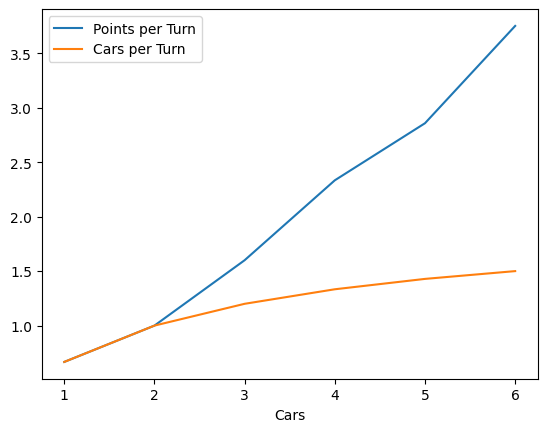

In [2]:
ROUTE_LENGTHS.plot(x="Cars", y=["Points per Turn", "Cars per Turn"])

## Routes Matrix

In [3]:
from collections import defaultdict
ROUTES_MATRIX = pd.read_csv("america_routes.csv").fillna(value=0)
def set_style(styler):
    styler.background_gradient(axis=None,cmap=sns.dark_palette("seagreen", as_cmap=True))
    styler.hide(axis=0) # Hides index column
    styler.format(precision=0)
    styler.set_table_styles(
    [dict(selector="th",props=[('max-width', '80px')]),
        dict(selector="th.col_heading",
                 props=[("writing-mode", "vertical-rl"), 
                        ('vertical-align', 'text-top'), ('transform', 'rotateZ(180deg)'),
                        ])])
    return styler
ROUTES_MATRIX.style.pipe(set_style)

City,Atlanta,Boston,Calgary,Charleston,Chicago,Dallas,Denver,Duluth,El Paso,Helena,Houston,Kansas City,Las Vegas,Little Rock,Los Angeles,Miami,Montreal,Nashville,New Orleans,New York,Oklahoma City,Omaha,Phoenix,Pittsburgh,Portland,Raleigh,Saint Louis,Salt Lake City,San Francisco,Santa Fe,Sault St. Marie,Seattle,Toronto,Vancouver,Washington,Winnipeg
Atlanta,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,5,0,1,4,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0
Boston,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Calgary,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,3,0,6
Charleston,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0
Chicago,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,3,0,0,2,0,0,0,0,0,4,0,0,0
Dallas,0,0,0,0,0,0,0,0,4,0,1,0,0,2,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Denver,0,0,0,0,0,0,0,0,0,4,0,4,0,0,0,0,0,0,0,0,4,4,5,0,0,0,0,3,0,2,0,0,0,0,0,0
Duluth,0,0,0,0,3,0,0,0,0,6,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,3,0,6,0,0,4
El Paso,0,0,0,0,0,4,0,0,0,0,6,0,0,0,6,0,0,0,0,0,5,0,3,0,0,0,0,0,0,2,0,0,0,0,0,0
Helena,0,0,4,0,0,0,4,6,0,0,0,0,0,0,0,0,0,0,0,0,0,5,0,0,0,0,0,3,0,0,0,6,0,0,0,4


## Visualizing the routes graph

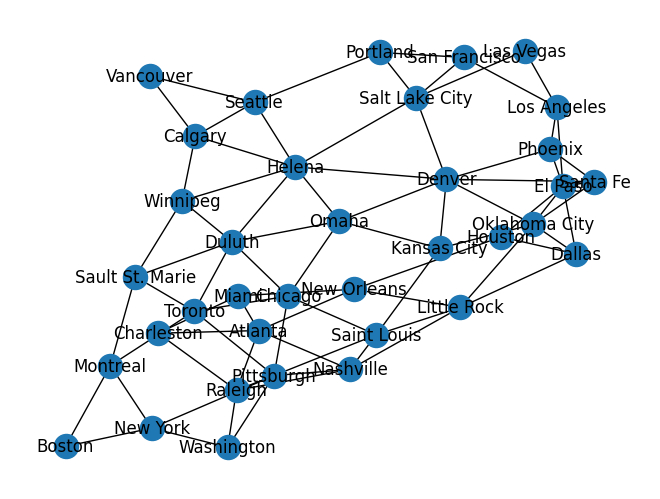

In [4]:
import networkx as nx
ROUTES_GRAPH_BY_TURNS = nx.Graph()
for i, row in ROUTES_MATRIX.iterrows():
    for j in range(1, len(row)):
        route_length = row[ROUTES_MATRIX.columns[j]]
        if route_length > 0:
            weight = ROUTE_LENGTHS.loc[ROUTE_LENGTHS["Cars"] == route_length, "Total Turns to Claim"].iloc[0] # TODO: also make a graph that weights by turns per point
            ROUTES_GRAPH_BY_TURNS.add_edge(i,j-1,weight=weight)
nx.draw(
    ROUTES_GRAPH_BY_TURNS, 
    with_labels=True, 
    labels={i-1: ROUTES_MATRIX.columns[i] for i in range(1, len(ROUTES_MATRIX.columns))},
)

## Solving for the best paths
Using the graph with edges weighted by the total number of turns to claim each route, we can calculate the steiner tree for a given set of cities we want to connect. This steiner tree will give us the set of routes to claim such that we complete these connections as fast as possible, lowering the risk of taking a ticket.

In [5]:
from networkx.algorithms.approximation import steiner_tree
from typing import List

def get_city_index(city_name: str) ->  int:
    return ROUTES_MATRIX.columns.get_loc(city_name)-1

def get_city_name(city_index: int) -> str:
    return ROUTES_MATRIX.columns[city_index+1]

def get_fastest_tree(cities: List[str]):
    """
    returns the total number of turns for the moveset and the list of routes to claim
    """
    cities_indices = [get_city_index(city) for city in cities]
    tree = steiner_tree(ROUTES_GRAPH_BY_TURNS, cities_indices, weight='weight') # NOTE: is an approximation
    return pd.Series([tree.size(weight='weight'), [(get_city_name(edge[0]), get_city_name(edge[1])) for edge in tree.edges]])

def get_route_length_for_route(origin: str, destination: str) -> int:
    route_length = ROUTES_MATRIX.loc[ROUTES_MATRIX["City"] == origin, destination].iloc[0]
    if route_length == 0:
        raise f"Cities {origin} {destination} not connected!"
    return route_length

def get_points_for_route_length(route_length: int) -> int:
    return ROUTE_LENGTHS.loc[ROUTE_LENGTHS["Cars"] == route_length, "Points"].iloc[0]

def get_routeset_points(routes: List[tuple[str,str]]) -> int:
    return sum(
        [get_points_for_route_length(get_route_length_for_route(origin, destination))
            for origin, destination in routes]
    )

def get_routeset_cars(routes: List[tuple[str,str]]) -> int:
    return sum(
        [get_route_length_for_route(origin, destination)
            for origin, destination in routes]
    )

## Value of Tickets

In [10]:
# Build ticket data frame
TICKETS = pd.read_csv("america_tickets.csv")
# TICKETS["Fastest Turns to Claim"], TICKETS["Path"]] = 
TICKETS[["Minimum Turns", "Minimum Routeset"]] = TICKETS.apply(lambda x: get_fastest_tree([x["Origin"], x["Destination"]]), axis=1)
TICKETS["Minimum Routeset Cars"] = TICKETS.apply(lambda x: get_routeset_cars(x["Minimum Routeset"]), axis=1)
TICKETS["Minimum Routeset Points"] = TICKETS.apply(lambda x: get_routeset_points(x["Minimum Routeset"]), axis=1)
TICKETS["Minimum Routeset Points per Turn"] = TICKETS.apply(lambda x: x["Minimum Routeset Points"]/x["Minimum Turns"], axis=1)
TICKETS["Minimum Routeset Cars per Turn"] = TICKETS.apply(lambda x: x["Minimum Routeset Cars"]/x["Minimum Turns"], axis=1)
TICKETS["Minimum Routeset Total Points per Turn"] = TICKETS.apply(lambda x: (x["Bonus Points"]+x["Minimum Routeset Points"])/x["Minimum Turns"], axis=1)

def set_style(styler):
    styler.background_gradient(axis=None,cmap=sns.dark_palette("seagreen", as_cmap=True), subset=["Bonus Points"])
    styler.background_gradient(axis=None,cmap=sns.dark_palette("seagreen", as_cmap=True), subset=["Minimum Routeset Cars"])
    styler.background_gradient(axis=None,cmap=sns.dark_palette("seagreen", as_cmap=True), subset=["Minimum Routeset Points"])
    styler.background_gradient(axis=None,cmap=sns.dark_palette("seagreen", as_cmap=True), subset=["Minimum Routeset Points per Turn"])
    styler.background_gradient(axis=None,cmap=sns.dark_palette("seagreen", as_cmap=True), subset=["Minimum Routeset Cars per Turn"])
    styler.background_gradient(axis=None,cmap=sns.dark_palette("seagreen", as_cmap=True), subset=["Minimum Routeset Total Points per Turn"])
    styler.background_gradient(axis=None,cmap=sns.dark_palette("seagreen", as_cmap=True), subset=["Minimum Routeset Total Points per Turn"])
    styler.background_gradient(axis=None,cmap=sns.dark_palette("seagreen", as_cmap=True).reversed(), subset=["Minimum Turns"])
    styler.hide(axis=0) # Hides index column
    # styler.hide(axis=1, subset=["Minimum Routeset"]) # TODO: find a better way to display?
    styler.format(precision=0, subset=["Bonus Points"])
    styler.format(precision=2)
    return styler
TICKETS.sort_values("Minimum Routeset Total Points per Turn", ascending=False).style.pipe(set_style)

Origin,Destination,Bonus Points,Minimum Turns,Minimum Routeset,Minimum Routeset Cars,Minimum Routeset Points,Minimum Routeset Points per Turn,Minimum Routeset Cars per Turn,Minimum Routeset Total Points per Turn
Los Angeles,Miami,20,14.00,"[('New Orleans', 'Houston'), ('New Orleans', 'Miami'), ('El Paso', 'Houston'), ('El Paso', 'Los Angeles')]",20.00,47,3.36,1.43,4.79
Vancouver,Montreal,20,14.00,"[('Montreal', 'Sault St. Marie'), ('Vancouver', 'Calgary'), ('Calgary', 'Winnipeg'), ('Winnipeg', 'Sault St. Marie')]",20.00,44,3.14,1.43,4.57
Seattle,New York,22,15.00,"[('New York', 'Pittsburgh'), ('Chicago', 'Duluth'), ('Chicago', 'Pittsburgh'), ('Duluth', 'Helena'), ('Helena', 'Seattle')]",20.00,40,2.67,1.33,4.13
Calgary,Phoenix,13,9.50,"[('Helena', 'Calgary'), ('Helena', 'Denver'), ('Denver', 'Phoenix')]",13.00,24,2.53,1.37,3.89
Los Angeles,Chicago,16,12.00,"[('Chicago', 'Omaha'), ('Omaha', 'Denver'), ('Denver', 'Phoenix'), ('Phoenix', 'Los Angeles')]",16.00,28,2.33,1.33,3.67
Vancouver,Santa Fe,13,10.50,"[('Vancouver', 'Seattle'), ('Denver', 'Helena'), ('Denver', 'Santa Fe'), ('Helena', 'Seattle')]",13.00,25,2.38,1.24,3.62
Denver,Pittsburgh,11,8.50,"[('Saint Louis', 'Kansas City'), ('Saint Louis', 'Pittsburgh'), ('Kansas City', 'Denver')]",11.00,19,2.24,1.29,3.53
Portland,Nashville,17,13.50,"[('Nashville', 'Saint Louis'), ('Denver', 'Kansas City'), ('Denver', 'Salt Lake City'), ('Portland', 'Salt Lake City'), ('Saint Louis', 'Kansas City')]",17.00,30,2.22,1.26,3.48
Portland,Phoenix,11,8.50,"[('Portland', 'San Francisco'), ('San Francisco', 'Los Angeles'), ('Phoenix', 'Los Angeles')]",11.00,18,2.12,1.29,3.41
Los Angeles,New York,21,16.50,"[('New York', 'Pittsburgh'), ('Chicago', 'Omaha'), ('Chicago', 'Pittsburgh'), ('Omaha', 'Denver'), ('Denver', 'Phoenix'), ('Phoenix', 'Los Angeles')]",21.00,34,2.06,1.27,3.33


## Steiner Forests for combinations of tickets
There are cases where we do not need to connect all of our cities to complete our tickets. Example: Denver-El Paso & New York-Atlanta.  In this case, we need to compare the sums of the steiner trees for each ticket destination pair to the steiner tree of the combined ticket destinations.

## Rush Strategy
This is a good benchmark to use to decide whether or not a set of tickets is worth pursuing, since this strategy is effectively always available to you
* Ignore tickets (take the minimum starting tickets, and only take the lowest valued ones)
* Claim the longest routes possible
* End the game as fast as possible

In [7]:
from collections import defaultdict

routes_claimed_sets = []
for number_of_sixroutes_allowed in reversed(range(1,8)):
    routes_claimed_set = {i:0 for i in range(1,7)}
    train_cars_remaining = TOTAL_TRAIN_CARS
    sixroutes_remaining = number_of_sixroutes_allowed
    while train_cars_remaining > 0:
        if train_cars_remaining <= 5:
            routes_claimed_set[train_cars_remaining] += 1
            train_cars_remaining = 0
            continue
        if sixroutes_remaining > 0:
            routes_claimed_set[6] += 1
            sixroutes_remaining -= 1
            train_cars_remaining -= 6
            continue
        routes_claimed_set[5] += 1
        train_cars_remaining -= 5
    routes_claimed_sets.append(routes_claimed_set)

RUSH_MOVESETS = pd.DataFrame(routes_claimed_sets)
RUSH_MOVESETS["Turns"] = sum(
        [RUSH_MOVESETS[rte_length] * ROUTE_LENGTHS.loc[ROUTE_LENGTHS["Cars"] == rte_length, "Total Turns to Claim"].iloc[0] for rte_length in range(1,7)]
    ) - STARTING_CARS/CARS_PER_TURN
RUSH_MOVESETS["Points"] = sum(
        [RUSH_MOVESETS[rte_length] * ROUTE_LENGTHS.loc[ROUTE_LENGTHS["Cars"] == rte_length, "Points"].iloc[0] for rte_length in range(1,7)]
    )
RUSH_MOVESETS["Points per Turn"] = RUSH_MOVESETS["Points"] / RUSH_MOVESETS["Turns"]
RUSH_MOVESETS["Cars per Turn"] = TOTAL_TRAIN_CARS / RUSH_MOVESETS["Turns"]
# TODO: Add average ticket loss/min ticket loss/max ticket loss

def set_style(styler):
    styler.background_gradient(cmap=sns.light_palette("seagreen", as_cmap=True).reversed(), subset=["Turns"])
    styler.background_gradient(cmap=sns.light_palette("seagreen", as_cmap=True), subset=["Points", "Points per Turn", "Cars per Turn"])
    styler.hide(axis=0) # Hides index column
    styler.format(precision=2)
    styler.format(precision=0, subset=["Turns"])
    return styler

RUSH_MOVESETS.style.pipe(set_style)

1,2,3,4,5,6,Turns,Points,Points per Turn,Cars per Turn
0,0,1,0,0,7,29,109,3.76,1.55
0,0,0,1,1,6,29,107,3.69,1.55
0,0,0,0,3,5,29,105,3.62,1.55
1,0,0,0,4,4,30,101,3.37,1.50
0,1,0,0,5,3,30,97,3.23,1.50
0,0,1,0,6,2,30,94,3.13,1.50
0,0,0,1,7,1,30,92,3.07,1.50
